# Flight Delay Prediction

## Weather Data Processing
- Exploring <strong>2016_1.json</strong> weather Data to generalize
- Loading the json file into a Data Frame
- Isolating the weather data and examining its column structure
- Flattening the nested structure based on the required columns
- Filtering the required data columns
- Combining all the weather data after data handling into a df
- Ensuring by visualizing that the data has no missing values
- Storing df as <strong>weather_data.csv</strong> in the <strong>Data</strong> directory

## Prerequisites

# Start from here

In [79]:
# تعريف المطارات بصيغة IATA و ICAO المطلوبة لموقع IEM
airports_to_fetch = {
    'ATL': 'KATL', 
    'CLT': 'KCLT', 
    'DEN': 'KDEN', 
    'DFW': 'KDFW',
    'EWR': 'KEWR', 
    'IAH': 'KIAH', 
    'JFK': 'KJFK', 
    'LAS': 'KLAS',
    'LAX': 'KLAX', 
    'MCO': 'KMCO', 
    'MIA': 'KMIA', 
    'ORD': 'KORD',
    'PHX': 'KPHX', 
    'SEA': 'KSEA', 
    'SFO': 'KSFO'
}

In [80]:
from datetime import datetime
import pandas as pd
from meteostat import Hourly

# 1. قائمة المطارات مع معرفات المحطات (Station IDs) الخاصة بـ Meteostat
# هذه الأكواد ثابتة ولا تتطلب دالة بحث
airport_stations = {
    'ATL': '72219', 'CLT': '72308', 'DEN': '72469', 'DFW': '72259',
    'EWR': '72502', 'IAH': '72243', 'JFK': '74486', 'LAS': '72386',
    'LAX': '72295', 'MCO': '72205', 'MIA': '72202', 'ORD': '72530',
    'PHX': '72278', 'SEA': '72793', 'SFO': '72494'
}

# 2. تحديد الفترة الزمنية
start = datetime(2024, 1, 1)
end = datetime(2025, 12, 31)

all_data = []

print("🚀 بدء جلب البيانات باستخدام المعرفات المباشرة...")

for iata_code, station_id in airport_stations.items():
    try:
        # جلب البيانات مباشرة باستخدام ID المحطة
        data = Hourly(station_id, start, end).fetch()
        
        if not data.empty:
            data['airport'] = iata_code
            all_data.append(data)
            print(f"✅ تم بنجاح: {iata_code}")
        else:
            print(f"⚠️ لا توجد بيانات متاحة: {iata_code}")
            
    except Exception as e:
        print(f"❌ خطأ في مطار {iata_code}: {e}")

# 3. معالجة البيانات وتصديرها
if all_data:
    df = pd.concat(all_data)
    
    # تحويلات القيم (Metric to Imperial) لتناسب طلبك
    df['tempF'] = (df['temp'] * 9/5) + 32
    df['DewPointF'] = (df['dwpt'] * 9/5) + 32
    df['windspeedKmph'] = df['wspd']
    df['winddirDegree'] = df['wdir']
    df['precipMM'] = df['prcp']
    df['pressure'] = df['pres']
    df['humidity'] = df['rhum']
    df['WindGustKmph'] = df['wpgt']
    df['date'] = df.index.date
    df['time'] = df.index.time
    
    # تعبئة الأعمدة المطلوبة غير المتوفرة بـ NaN للحفاظ على الهيكل
    df['weatherCode'] = df['coco'] if 'coco' in df.columns else None
    df['visibility'] = None
    df['cloudcover'] = None
    df['WindChillF'] = None

    final_columns = [
        "windspeedKmph","winddirDegree", "weatherCode","precipMM","visibility",
        "pressure","cloudcover","DewPointF","WindGustKmph","tempF",
        "WindChillF","humidity","date","time","airport"
    ]
    
    final_df = df.reindex(columns=final_columns)
    
    # حفظ الملف
    # file_name = "meteostat_weather_data.csv"
    final_df.head()
    # final_df.to_csv(file_name, index=False)
    # print(f"\n✨ انتهى! تم حفظ {len(final_df)} سطر في الملف: {file_name}")
else:
    print("\n❌ لم يتم جلب أي بيانات. تأكد من تثبيت المكتبة بشكل صحيح: pip install meteostat")

🚀 بدء جلب البيانات باستخدام المعرفات المباشرة...
✅ تم بنجاح: ATL
✅ تم بنجاح: CLT
✅ تم بنجاح: DEN
✅ تم بنجاح: DFW
✅ تم بنجاح: EWR
✅ تم بنجاح: IAH
✅ تم بنجاح: JFK
✅ تم بنجاح: LAS
✅ تم بنجاح: LAX
✅ تم بنجاح: MCO
✅ تم بنجاح: MIA
✅ تم بنجاح: ORD
✅ تم بنجاح: PHX
✅ تم بنجاح: SEA
✅ تم بنجاح: SFO


In [81]:
# الجزء 3 المعدل: معالجة أولية فقط
if all_data:
    df = pd.concat(all_data)
    
    # تحويلات القيم الأساسية فقط
    df['tempF'] = (df['temp'] * 9/5) + 32
    df['DewPointF'] = (df['dwpt'] * 9/5) + 32
    df['windspeedKmph'] = df['wspd']
    df['winddirDegree'] = df['wdir']
    df['precipMM'] = df['prcp']
    df['pressure'] = df['pres']
    df['humidity'] = df['rhum']
    df['WindGustKmph'] = df['wpgt']
    df['weatherCode'] = df['coco'] # نترك الكود الأصلي كما هو حالياً

    # فك الـ Index واستخراج الوقت بدقة لتجنب التكرار
    df = df.reset_index()
    df = df.rename(columns={'time': 'full_timestamp'}) 
    df['date'] = df['full_timestamp'].dt.date
    df['time'] = df['full_timestamp'].dt.time
    
    # إنشاء أعمدة فارغة تماماً للبيانات التي سنأخذها من IEM
    df['visibility'] = None 
    df['cloudcover'] = None
    df['WindChillF'] = None 

    final_columns = [
        "windspeedKmph", "winddirDegree", "weatherCode", "precipMM", "visibility",
        "pressure", "cloudcover", "DewPointF", "WindGustKmph", "tempF",
        "WindChillF", "humidity", "date", "time", "airport"
    ]
    
    # DataFrame الأساسي (خام وبه قيم Null)
    df_meteostat_raw = df.loc[:, ~df.columns.duplicated()][final_columns]
    print("✅ تم تجهيز بيانات Meteostat الخام بنجاح.")
    file_name = "Data/meteostat_weather_data.csv"
    final_df.to_csv(file_name, index=False)
    print(f"\n✨ انتهى! تم حفظ {len(final_df)} سطر في الملف: {file_name}")

✅ تم تجهيز بيانات Meteostat الخام بنجاح.

✨ انتهى! تم حفظ 262815 سطر في الملف: Data/meteostat_weather_data.csv


In [82]:
import requests, io, time
from datetime import datetime

def fetch_iem_data(mapping):
    all_dfs = []
    # خريطة تحويل الغيوم النصية لأرقام
    cloud_map = {'CLR': 0, 'SKC': 0, 'FEW': 25, 'SCT': 50, 'BKN': 75, 'OVC': 100, 'VV ': 100}

    print("🚀 جاري سحب بيانات IEM...")
    for iata, icao in mapping.items():
        url = (f"https://mesonet.agron.iastate.edu/cgi-bin/request/asos.py?"
               f"station={icao}&data=vsby&data=gust&data=skyc1&year1=2024&month1=1&day1=1"
               f"&year2=2025&month2=12&day2=31&tz=Etc%2FUTC&format=comma")
        try:
            res = requests.get(url, timeout=30)
            df_tmp = pd.read_csv(io.StringIO(res.text[res.text.find("station"):]))
            if not df_tmp.empty:
                df_tmp['valid'] = pd.to_datetime(df_tmp['valid'])
                df_tmp['date'] = df_tmp['valid'].dt.date
                df_tmp['time'] = df_tmp['valid'].dt.round('H').dt.time
                
                # تحويل الوحدات لـ IEM
                df_tmp['visibility_iem'] = pd.to_numeric(df_tmp['vsby'], errors='coerce') * 1.609
                df_tmp['windgust_iem'] = pd.to_numeric(df_tmp['gust'], errors='coerce') * 1.852
                df_tmp['cloudcover_iem'] = df_tmp['skyc1'].str.strip().map(cloud_map)
                
                all_dfs.append(df_tmp[['date', 'time', 'station', 'visibility_iem', 'windgust_iem', 'cloudcover_iem']])
                print(f"✅ تم جلب: {iata}")
        except: print(f"❌ فشل: {iata}")
        time.sleep(0.3)

    iem_full = pd.concat(all_dfs).drop_duplicates(subset=['station', 'date', 'time'])
    return iem_full

# نستخدم قاموس المطارات الذي يحتوي على رموز ICAO (مثل KATL)
iem_raw_data = fetch_iem_data(airports_to_fetch)

🚀 جاري سحب بيانات IEM...


✅ تم جلب: ATL


✅ تم جلب: CLT


✅ تم جلب: DEN


✅ تم جلب: DFW


...

✅ تم جلب: MIA


✅ تم جلب: ORD


✅ تم جلب: PHX


✅ تم جلب: SEA


✅ تم جلب: SFO


In [84]:
# Save the IEM Collected Data
iem_raw_data.to_csv("Data/iem_verified_weather_data.csv", index=False)

In [85]:
df_meteostat_raw['datetime'] = pd.to_datetime(
    df_meteostat_raw['date'].astype(str) + ' ' +
    df_meteostat_raw['time'].astype(str)
).dt.tz_localize(None)

iem_raw_data['datetime'] = pd.to_datetime(
    iem_raw_data['date'].astype(str) + ' ' + iem_raw_data['time'].astype(str)
)

def merge_weather_by_nearest_time(meteostat_df, iem_df):
    meteostat_work = meteostat_df.copy()
    iem_work       = iem_df.copy()

    # توحيد عمود airport في Meteostat
    meteostat_work['airport'] = meteostat_work['airport'].astype(str).str.strip().str.upper()

    # ✅ الإصلاح: IEM يُرجع IATA مباشرة (ATL وليس KATL) — نستخدمه كما هو
    iem_work['airport'] = iem_work['station'].astype(str).str.strip().str.upper()

    # إزالة التكرار والترتيب (شرط merge_asof)
    meteostat_work = meteostat_work.drop_duplicates(subset=['airport', 'datetime'])
    iem_work       = iem_work.drop_duplicates(subset=['airport', 'datetime'])
    meteostat_work = meteostat_work.sort_values('datetime')
    iem_work       = iem_work.sort_values('datetime')

    print("🔄 جاري الدمج الذكي (Nearest Merge)...")

    try:
        merged = pd.merge_asof(
            meteostat_work,
            iem_work[['airport', 'datetime',
                       'visibility_iem', 'windgust_iem', 'cloudcover_iem']],
            on='datetime',
            by='airport',
            direction='nearest',
            tolerance=pd.Timedelta('1h')
        )

        merged['visibility']   = merged['visibility_iem']
        merged['cloudcover']   = merged['cloudcover_iem']
        merged['WindGustKmph'] = merged['windgust_iem'].fillna(merged['WindGustKmph'])
        merged['WindChillF']   = merged['tempF']

        successful_merges = merged['visibility_iem'].notna().sum()
        return merged, successful_merges

    except Exception as e:
        print(f"❌ فشل الدمج: {e}")
        return None, 0

df_combined, success_count = merge_weather_by_nearest_time(df_meteostat_raw, iem_raw_data)

🔄 جاري الدمج الذكي (Nearest Merge)...


In [86]:
def analyze_data_v3(dataframe, successful_merges=0):
    """
    دالة شاملة لتحليل جودة البيانات وعرض إحصائيات الدمج والقيم المفقودة.
    """
    total_rows = len(dataframe)
    
    print("\n" + "="*70)
    print(f"{'📊 تقرير جودة البيانات النهائي':^70}")
    print("="*70)
    
    # 1. إحصائيات عامة
    print(f"{'STATISTIC':<35} | {'VALUE':<30}")
    print("-" * 70)
    print(f"{'Total Rows in Dataset':<35} | {total_rows:<30}")
    
    # إذا كان هناك دمج، نعرض إحصائياته
    if successful_merges > 0:
        print(f"{'Successfully Merged (IEM)':<35} | {successful_merges:<30}")
        print(f"{'Merge Success Rate':<35} | {(successful_merges/total_rows)*100:.2f}%")
    
    print("-" * 70)
    
    # 2. تحليل الأعمدة
    print(f"{'Column Name':<20} | {'Nulls':<10} | {'Unique Count':<15} | {'Data Type':<15}")
    print("-" * 70)
    
    # قائمة الأعمدة المراد تحليلها (الترتيب الذي تفضله)
    cols_to_analyze = [
        "windspeedKmph", "winddirDegree", "weatherCode", "precipMM", "visibility",
        "pressure", "cloudcover", "DewPointF", "WindGustKmph", "tempF",
        "WindChillF", "humidity", "date", "time", "airport"
    ]
    
    for col in cols_to_analyze:
        if col in dataframe.columns:
            null_count = dataframe[col].isna().sum()
            unique_count = dataframe[col].nunique()
            dtype = str(dataframe[col].dtype)
            
            print(f"{col:<20} | {null_count:<10} | {unique_count:<15} | {dtype:<15}")
            
            # عرض عينة من القيم الفريدة للأعمدة التصنيفية أو ذات القيم القليلة
            if unique_count <= 10 and unique_count > 0:
                print(f"   💡 Unique Values: {list(dataframe[col].unique())}")
                
    print("=" * 70)
    
    # 3. فحص منطقي سريع (Data Health Check)
    print(f"{'🔍 فحص المنطق الصحي للبيانات':^70}")
    print("-" * 70)
    if 'WindGustKmph' in dataframe.columns and 'windspeedKmph' in dataframe.columns:
        logic_check = (dataframe['WindGustKmph'] >= dataframe['windspeedKmph']).all()
        status = "✅ سليم" if logic_check else "⚠️ هناك قيم (Gust) أصغر من السرعة العادية"
        print(f"Check: (WindGust >= WindSpeed) -> {status}")
        
    if 'tempF' in dataframe.columns:
        print(f"Temperature Range: {dataframe['tempF'].min():.1f}°F to {dataframe['tempF'].max():.1f}°F")
        
    print("=" * 70 + "\n")

In [87]:
analyze_data_v3(df_combined, success_count)


                    📊 تقرير جودة البيانات النهائي                     
STATISTIC                           | VALUE                         
----------------------------------------------------------------------
Total Rows in Dataset               | 262815                        
Successfully Merged (IEM)           | 262005                        
Merge Success Rate                  | 99.69%
----------------------------------------------------------------------
Column Name          | Nulls      | Unique Count    | Data Type      
----------------------------------------------------------------------
windspeedKmph        | 0          | 106             | Float64        
winddirDegree        | 1          | 361             | Float64        
weatherCode          | 124        | 19              | Float64        
precipMM             | 20689      | 184             | Float64        
visibility           | 810        | 23              | float64        
pressure             | 722        | 631    

In [88]:
def finalize_aviation_data(df):
    working_df = df.copy()
    
    # 1. قائمة الأعمدة الرقمية التي سنعالجها
    numeric_cols = [
        "windspeedKmph", "winddirDegree", "weatherCode", "precipMM", "visibility",
        "pressure", "cloudcover", "DewPointF", "WindGustKmph", "tempF",
        "WindChillF", "humidity"
    ]
    
    print("🪄 جاري سد الثغرات البسيطة المتبقية وتصحيح المنطق الفيزيائي...")

    # تحويل الأعمدة لنوع رقمي لضمان عمل الدالة
    for col in numeric_cols:
        working_df[col] = pd.to_numeric(working_df[col], errors='coerce')

    # 2. الاستكمال الرياضي (Interpolation) لكل مطار على حدة
    working_df[numeric_cols] = working_df.groupby('airport')[numeric_cols].transform(
        lambda x: x.interpolate(method='linear', limit_direction='both')
    )

    # 3. معالجة الحالات الخاصة بعد الاستكمال
    
    # أ. معالجة الهبوب (WindGust):
    # أولاً: ملء القيم المفقودة تماماً بسرعة الرياح العادية
    working_df['WindGustKmph'] = working_df['WindGustKmph'].fillna(working_df['windspeedKmph'])
    # ثانياً: حل مشكلة التداخل الرياضي (التأكد أن الهبوب >= سرعة الرياح)
    working_df['WindGustKmph'] = working_df[['WindGustKmph', 'windspeedKmph']].max(axis=1)
    
    # ب. معالجة الغيوم: ملء أي Null متبقي بـ 0 (صافي)
    working_df['cloudcover'] = working_df['cloudcover'].fillna(method='ffill').fillna(0)
    
    # ج. معالجة المطر: أي Null يعني عدم وجود مطر
    working_df['precipMM'] = working_df['precipMM'].fillna(0)
    
    # د. معالجة weatherCode: تحويله لرقم صحيح
    working_df['weatherCode'] = working_df['weatherCode'].fillna(1).astype(int)

    # 4. تأكيد نهائي لعدم وجود أي Null
    working_df = working_df.ffill().bfill()
    
    print("✅ اكتمل العمل! البيانات الآن جاهزة 100% (تم حل مشكلة Gust بنجاح).")
    return working_df

# تشغيل الكود النهائي
df_ready_to_train = finalize_aviation_data(df_combined)

🪄 جاري سد الثغرات البسيطة المتبقية وتصحيح المنطق الفيزيائي...


✅ اكتمل العمل! البيانات الآن جاهزة 100% (تم حل مشكلة Gust بنجاح).


In [89]:
# التحليل النهائي للتأكد من اكتمال البيانات بنسبة 100%
analyze_data_v3(df_ready_to_train, success_count)


                    📊 تقرير جودة البيانات النهائي                     
STATISTIC                           | VALUE                         
----------------------------------------------------------------------
Total Rows in Dataset               | 262815                        
Successfully Merged (IEM)           | 262005                        
Merge Success Rate                  | 99.69%
----------------------------------------------------------------------
Column Name          | Nulls      | Unique Count    | Data Type      
----------------------------------------------------------------------
windspeedKmph        | 0          | 106             | Float64        
winddirDegree        | 0          | 361             | Float64        
weatherCode          | 0          | 21              | int64          
precipMM             | 0          | 1044            | Float64        
visibility           | 0          | 76              | float64        
pressure             | 0          | 1086   

In [90]:
df_ready_to_train.head()

,windspeedKmph,winddirDegree,weatherCode,precipMM,visibility,pressure,cloudcover,DewPointF,WindGustKmph,tempF,WindChillF,humidity,date,time,airport,datetime,visibility_iem,windgust_iem,cloudcover_iem
0,7.6,220.0,3,0.0,16.090,1020.4,0.0,32.0,35.188,48.92,48.92,52.0,2024-01-01,00:00:00,ATL,2024-01-01,16.090,31.484,0.0
1,13.0,220.0,3,0.0,16.090,1016.7,100.0,26.06,29.632,42.98,42.98,51.0,2024-01-01,00:00:00,EWR,2024-01-01,16.090,31.484,100.0
2,27.7,320.0,14,0.0,14.481,1017.4,100.0,28.22,31.484,33.08,33.08,82.0,2024-01-01,00:00:00,ORD,2024-01-01,14.481,31.484,100.0
3,0.0,0.0,1,0.0,16.090,1017.1,0.0,33.98,35.188,42.08,42.08,73.0,2024-01-01,00:00:00,CLT,2024-01-01,16.090,31.484,0.0
4,7.6,20.0,4,0.0,11.263,1018.4,100.0,49.82,31.484,55.94,55.94,80.0,2024-01-01,00:00:00,SFO,2024-01-01,11.263,31.484,100.0


In [91]:
df_ready_to_train.columns

Index(['windspeedKmph', 'winddirDegree', 'weatherCode', 'precipMM',
       'visibility', 'pressure', 'cloudcover', 'DewPointF', 'WindGustKmph',
       'tempF', 'WindChillF', 'humidity', 'date', 'time', 'airport',
       'datetime', 'visibility_iem', 'windgust_iem', 'cloudcover_iem'],
      dtype='object')

In [92]:
df_ready_to_train.tail()

,windspeedKmph,winddirDegree,weatherCode,precipMM,visibility,pressure,cloudcover,DewPointF,WindGustKmph,tempF,WindChillF,humidity,date,time,airport,datetime,visibility_iem,windgust_iem,cloudcover_iem
262810,0.0,0.0,3,0.0,16.09,1025.0,50.0,19.22,25.928,55.4,55.4,24.0,2025-12-31,00:00:00,LAS,2025-12-31,16.09,38.892,50.0
262811,33.0,280.0,3,0.0,16.09,1009.0,75.0,8.78,59.264,28.4,28.4,43.0,2025-12-31,00:00:00,JFK,2025-12-31,16.09,59.264,75.0
262812,28.0,260.0,3,0.0,16.09,1009.0,75.0,6.62,55.56,28.4,28.4,39.0,2025-12-31,00:00:00,EWR,2025-12-31,16.09,55.560,75.0
262813,17.0,330.0,2,0.0,16.09,1018.0,75.0,37.04,38.892,60.8,60.8,41.0,2025-12-31,00:00:00,MIA,2025-12-31,16.09,38.892,75.0
262814,7.0,110.0,3,0.0,16.09,1021.0,25.0,42.62,19.0,51.8,51.8,71.0,2025-12-31,00:00:00,SFO,2025-12-31,16.09,38.892,25.0


In [93]:
# print(df_ready_to_train['weatherCode'].unique())
# print(df_ready_to_train['WindGustKmph'].unique())
print(df_ready_to_train['cloudcover'].unique())
# print(df_ready_to_train['precipMM'].unique())

[  0.         100.          50.          25.          75.
  12.5          6.25        41.66666667  33.33333333  18.75
   8.33333333  16.66666667  20.83333333  16.66666667   8.33333333
   4.16666667   2.5          5.           7.5         10.
  15.          17.5         20.          22.5          4.16666667
  20.83333333   1.92307692   3.84615385   5.76923077   7.69230769
   9.61538462  11.53846154  13.46153846  15.38461538  17.30769231
  19.23076923  21.15384615  23.07692308  93.75        87.5
  81.25        68.75        62.5         56.25        30.
  45.          60.           9.375       28.125       37.5
  46.875       65.625       23.4375      21.875       20.3125
  17.1875      15.625       14.0625      10.9375       7.8125
   4.6875       3.125        1.5625      22.91666667  14.58333333
  10.41666667   2.08333333  43.75        28.57142857  32.14285714
  35.71428571  39.28571429  42.85714286  46.42857143  33.33333333
  41.66666667   1.66666667   3.33333333   6.66666667  11.66666

In [94]:
# 1. تحديد قائمة الأعمدة التي نريد الاحتفاظ بها فقط
final_columns = [
    'airport', 'date', 'time', 'tempF', 'WindChillF', 'humidity', 
    'windspeedKmph', 'WindGustKmph', 'winddirDegree', 'weatherCode', 
    'precipMM', 'visibility', 'pressure', 'cloudcover','DewPointF'
]

# 2. تصفية الجدول لإبقاء هذه الأعمدة فقط وبالترتيب المذكور
df_ready_to_train = df_ready_to_train[final_columns]

# 3. عرض التقرير النهائي للتأكد من نظافة الجدول
print("✨ تم تنظيف الجدول وحذف الأعمدة المساعدة.")
analyze_data_v3(df_ready_to_train, success_count)

✨ تم تنظيف الجدول وحذف الأعمدة المساعدة.

                    📊 تقرير جودة البيانات النهائي                     
STATISTIC                           | VALUE                         
----------------------------------------------------------------------
Total Rows in Dataset               | 262815                        
Successfully Merged (IEM)           | 262005                        
Merge Success Rate                  | 99.69%
----------------------------------------------------------------------
Column Name          | Nulls      | Unique Count    | Data Type      
----------------------------------------------------------------------
windspeedKmph        | 0          | 106             | Float64        
winddirDegree        | 0          | 361             | Float64        
weatherCode          | 0          | 21              | int64          
precipMM             | 0          | 1044            | Float64        
visibility           | 0          | 76              | float64        
pr

In [95]:
df_ready_to_train.columns

Index(['airport', 'date', 'time', 'tempF', 'WindChillF', 'humidity',
       'windspeedKmph', 'WindGustKmph', 'winddirDegree', 'weatherCode',
       'precipMM', 'visibility', 'pressure', 'cloudcover', 'DewPointF'],
      dtype='object')

In [96]:
# حفظ الملف
file_name = "Data/Aviation_Weather_Final_Dataset.csv"
df_ready_to_train.to_csv(file_name, index=False)
print(f"\n✨ تم الحل! الجدول الآن نظيف وجاهز. تم حفظه في: {file_name}")


✨ تم الحل! الجدول الآن نظيف وجاهز. تم حفظه في: Data/Aviation_Weather_Final_Dataset.csv


## Exploratory Data Analysis

## Checking for Missing Data

Axes(0.125,0.11;0.698618x0.77)
airport          0
date             0
time             0
tempF            0
WindChillF       0
humidity         0
windspeedKmph    0
WindGustKmph     0
winddirDegree    0
weatherCode      0
precipMM         0
visibility       0
pressure         0
cloudcover       0
DewPointF        0
dtype: int64


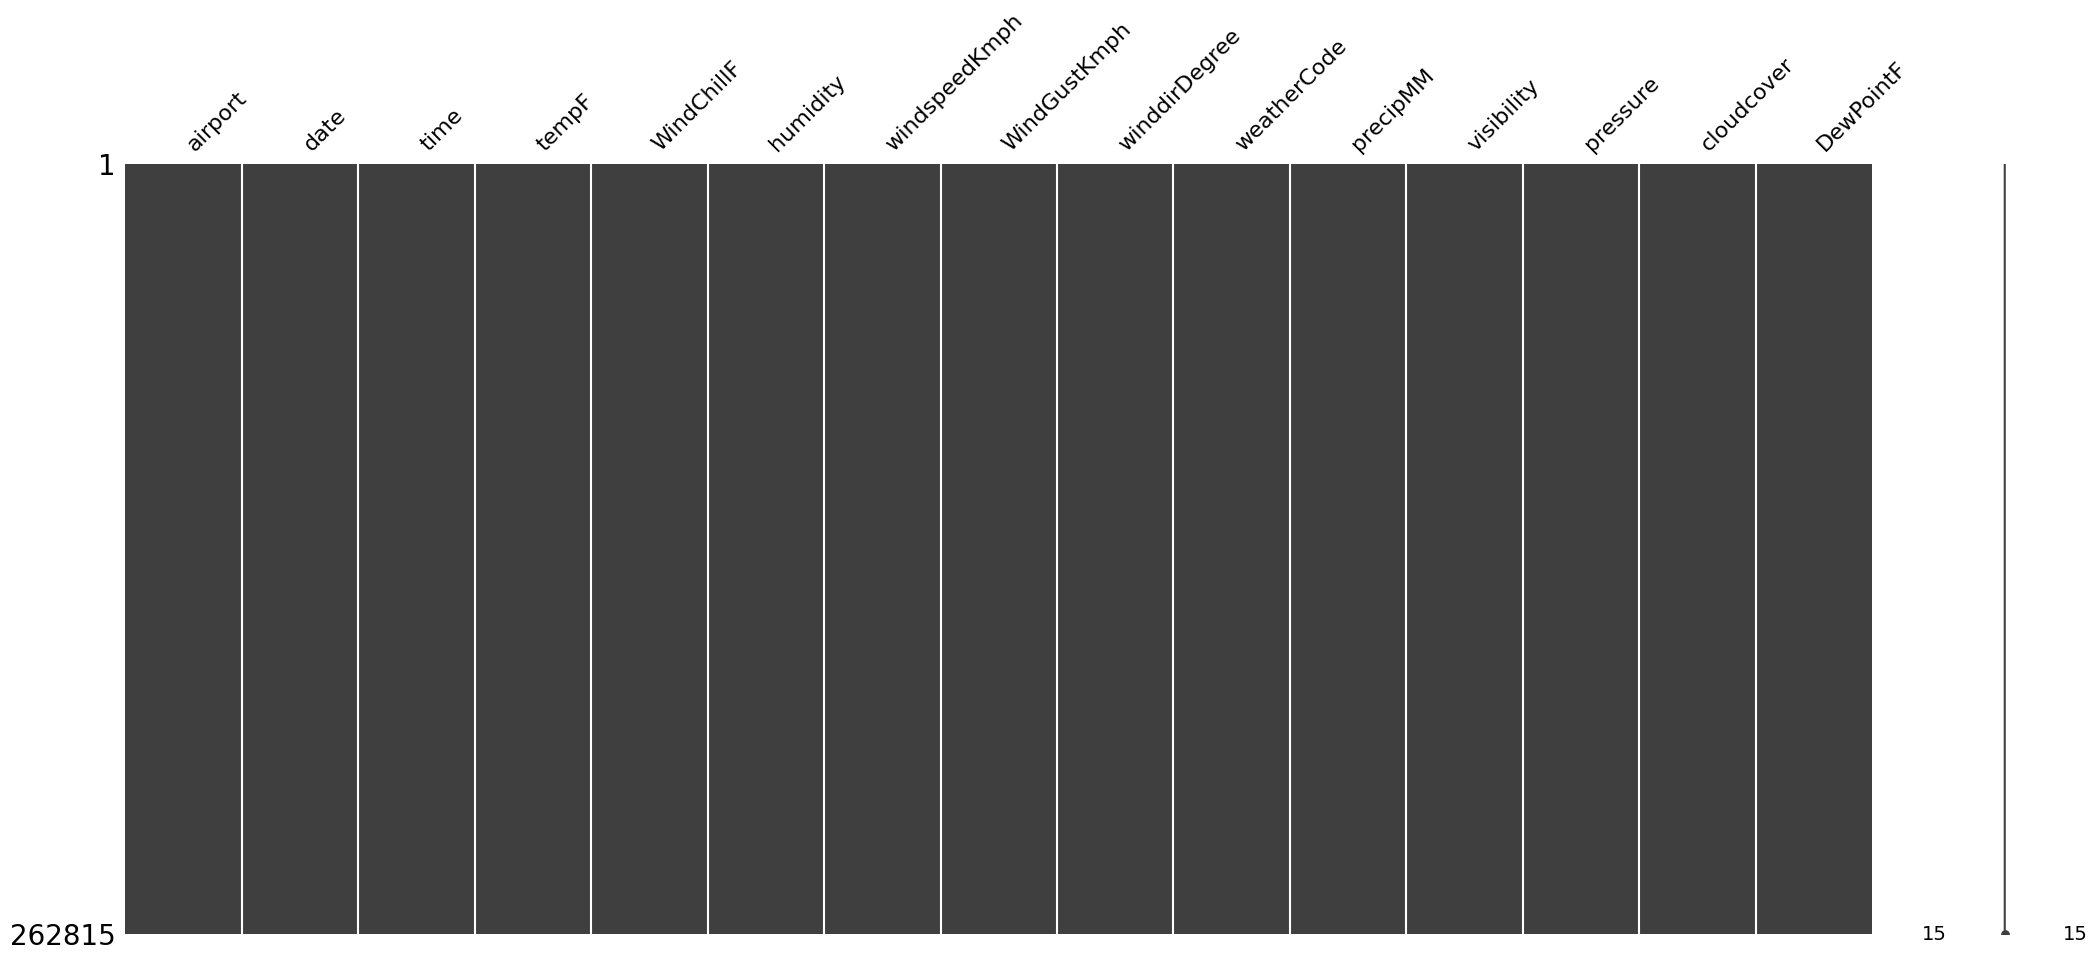

In [97]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt


print(msno.matrix(df_ready_to_train))
print(df_ready_to_train.isnull().sum())

In [98]:
print(df_ready_to_train.shape, end="\n\n")

(262815, 15)



## Checking for Duplicates
There won't duplicates in this data since the weather data was collected hourly (<strong>time</strong> column) from jan to dec for 2016 and 2017. <br>
In other words, (date, time) is the PRIMARY KEY

In [99]:
df_ready_to_train.drop_duplicates()
print(df_ready_to_train.shape, end="\n\n")

(262815, 15)

